# Chapter 19 — Mesh Network Technologies: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end. All exercises run in Google Colab with no
> additional hardware.

| Exercise | Topic | Key technique | Technology framing |
|----------|-------|----------------|----------------------|
| 19.1 | Route discovery: hop count vs. link-quality cost | Generic ETX and a ZigBee-inspired discretised link cost | ZigBee |
| 19.2 | Network formation | Leader election, REED promotion, distance-vector cost propagation | Thread |
| 19.3 | Self-healing | Router-failure Monte Carlo with End-Device parent reselection | ZigBee, Thread |
| 19.4 | Energy and capacity | Battery-life model; relay-load / offered-relay-airtime bottleneck | ZigBee, Thread |

**A role-correct mesh model.** Every exercise builds on the same network
generator: a connected *Router backbone* is generated first and verified
connected; End Devices are then attached, each to exactly one backbone
Router chosen as its best available parent. End Devices can therefore
never appear as intermediate hops on anyone else's path — matching how
ZigBee and Thread actually behave.

---
## Setup

Defines the shared physical-layer link model (an *illustrative* PRR
model informed by, but not calibrated against, the transitional-region
literature), three routing metrics (hop count, generic ETX, and a
ZigBee-style discretised cost), a Thread-style LQI-to-cost mapping, and
the role-correct backbone+leaves network generator used by every
exercise below.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

np.random.seed(42)
plt.rcParams.update({
    'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': 0.25,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'lines.linewidth': 1.8,
})

# ---------------------------------------------------------------------
# Illustrative physical-layer link model (NOT a calibrated propagation
# model). Radio parameters representative of the TI CC2652R (2.4 GHz
# IEEE 802.15.4 Thread/Zigbee SoC).
# ---------------------------------------------------------------------
TX_POWER_DBM, SENSITIVITY_DBM = 0.0, -100.0
PATHLOSS_EXP, PL_D0_DB, D0_M = 2.8, 40.2, 1.0
MARGIN0_DB, PRR_SLOPE_DB = 4.0, 3.0
SHADOW_SIGMA_DB = 2.0            # small fixed per-edge shadowing (obstacles/clutter)
EDGE_PRR_MIN = 0.5               # moderately permissive "in range" cutoff (ETX=4 there)
MAX_ACTIVE_ROUTERS = 32          # Thread's per-partition active-router ceiling

def path_loss_db(d_m):
    d_m = np.maximum(np.asarray(d_m, dtype=float), 0.5)
    return PL_D0_DB + 10 * PATHLOSS_EXP * np.log10(d_m / D0_M)

def _edge_shadow_db(i, j, seed):
    rng = np.random.default_rng(np.random.SeedSequence([seed, min(i, j), max(i, j)]))
    return rng.normal(0.0, SHADOW_SIGMA_DB)

def link_margin_db(d_m, shadow_db=0.0):
    return TX_POWER_DBM - (path_loss_db(d_m) + shadow_db) - SENSITIVITY_DBM

def prr(d_m, shadow_db=0.0):
    m = link_margin_db(d_m, shadow_db)
    return 1.0 / (1.0 + np.exp(-(m - MARGIN0_DB) / PRR_SLOPE_DB))

def p_transaction(d_m, shadow_db=0.0):
    '''p = PRR^2. This same transaction-success definition is used
    consistently wherever an ETX weight is assigned in this notebook.'''
    return prr(d_m, shadow_db) ** 2

def etx_generic(d_m, shadow_db=0.0):
    '''Generic Expected Transmission Count (De Couto et al., 2003):
    illustrates link-quality-aware routing in general -- NOT a
    reproduction of ZigBee's normative NWK link-cost formula.'''
    return 1.0 / p_transaction(d_m, shadow_db)

def zigbee_link_cost(d_m, shadow_db=0.0):
    '''ZigBee-INSPIRED illustrative discretised cost (1=best..7=worst),
    NOT the normative NWK-layer formula.'''
    p = prr(d_m, shadow_db)
    if p < EDGE_PRR_MIN:
        return np.inf
    frac = (p - EDGE_PRR_MIN) / (1.0 - EDGE_PRR_MIN)
    return float(np.clip(round(7 - 6 * frac), 1, 7))

THREAD_LINK_COST = {3: 1, 2: 3, 1: 6, 0: np.inf}   # Thread-INSPIRED illustrative mapping

def lqi_bucket(p):
    if p >= 0.99: return 3
    elif p >= 0.90: return 2
    elif p >= EDGE_PRR_MIN: return 1
    return 0

def thread_cost(d_m, shadow_db=0.0):
    return THREAD_LINK_COST[lqi_bucket(prr(d_m, shadow_db))]

# ---------------------------------------------------------------------
# Role-correct network generator: a CONNECTED Router backbone is built
# first; End Devices are then attached as LEAVES to a single best
# reachable parent. End Devices are NEVER used as intermediate relays.
# ---------------------------------------------------------------------
def _try_generate_backbone(n_routers, width_m, height_m, seed):
    rng = np.random.default_rng(seed)
    pos = rng.uniform([0, 0], [width_m, height_m], size=(n_routers, 2))
    pos[0] = [width_m / 2, height_m / 2]
    B = nx.Graph()
    for i in range(n_routers):
        B.add_node(i, pos=tuple(pos[i]), role='Router')
    for i in range(n_routers):
        for j in range(i + 1, n_routers):
            d = np.linalg.norm(pos[i] - pos[j])
            sh = _edge_shadow_db(i, j, seed)
            p = prr(d, sh)
            if p >= EDGE_PRR_MIN:
                B.add_edge(i, j, dist=d, prr=p, shadow=sh, etx=etx_generic(d, sh),
                           zcost=zigbee_link_cost(d, sh), tcost=thread_cost(d, sh))
    return B, pos

def generate_network(n_routers=27, n_enddevices=38, width_m=400, height_m=300, seed=42):
    assert n_routers <= MAX_ACTIVE_ROUTERS
    attempt = 0
    while True:
        s = seed + 10_000 * attempt
        B, pos_r = _try_generate_backbone(n_routers, width_m, height_m, s)
        if nx.is_connected(B):
            rng = np.random.default_rng(s + 1)
            pos_e = rng.uniform([0, 0], [width_m, height_m], size=(n_enddevices, 2))
            parent_map, ok = {}, True
            for k in range(n_enddevices):
                node_id = n_routers + k
                best_parent, best_p = None, 0.0
                for r in range(n_routers):
                    d = np.linalg.norm(pos_e[k] - pos_r[r])
                    sh = _edge_shadow_db(node_id, r, s)
                    p = prr(d, sh)
                    if p >= EDGE_PRR_MIN and p > best_p:
                        best_parent, best_p, best_d, best_sh = r, p, d, sh
                if best_parent is None:
                    ok = False; break
                parent_map[node_id] = dict(parent=best_parent, dist=best_d, prr=best_p,
                                            shadow=best_sh, etx=etx_generic(best_d, best_sh),
                                            zcost=zigbee_link_cost(best_d, best_sh),
                                            tcost=thread_cost(best_d, best_sh))
            if ok:
                pos_all = {i: tuple(pos_r[i]) for i in range(n_routers)}
                pos_all.update({n_routers + k: tuple(pos_e[k]) for k in range(n_enddevices)})
                return B, pos_all, parent_map, s
        attempt += 1
        if attempt > 200:
            raise RuntimeError("could not generate a valid connected deployment")

def spanning_tree_backbone(B, root, weight='etx'):
    '''Shortest-path TREE of the backbone -- no redundant router-router
    links, as in ZigBee's original tree-routing mode.'''
    _, paths = nx.single_source_dijkstra(B, root, weight=weight)
    T = nx.Graph(); T.add_nodes_from(B.nodes(data=True))
    for target, path in paths.items():
        for u, v in zip(path[:-1], path[1:]):
            if not T.has_edge(u, v):
                T.add_edge(u, v, **B.edges[u, v])
    return T

def candidate_parents(pos_ed, pos_routers, router_ids, seed_base, ed_id):
    cands = []
    for r in router_ids:
        d = np.linalg.norm(np.array(pos_ed) - np.array(pos_routers[r]))
        sh = _edge_shadow_db(ed_id, r, seed_base)
        p = prr(d, sh)
        if p >= EDGE_PRR_MIN:
            cands.append((r, p, d, sh))
    cands.sort(key=lambda c: -c[1])
    return cands

nominal_range = 10**(((TX_POWER_DBM - SENSITIVITY_DBM - MARGIN0_DB) - PL_D0_DB) / (10*PATHLOSS_EXP))
print(f"Toolkit ready. Nominal (50%-PRR) range: {nominal_range:.1f} m")

Toolkit ready. Nominal (50%-PRR) range: 98.4 m


---

## Exercise 19.1: Route Discovery — Hop Count, Generic ETX, and a ZigBee-Style Link Cost


In [2]:
# ── Exercise 19.1: mesh backbone generation ─────────────────────────────
B, pos, pm, seed_used = generate_network(n_routers=27, n_enddevices=38,
                                          width_m=400, height_m=300, seed=42)
root = 0
print(f"Router backbone: {B.number_of_nodes()} devices, {B.number_of_edges()} links, "
      f"connected = {nx.is_connected(B)}")
print(f"End Devices (leaves only): {len(pm)}")
degs = [d for _, d in B.degree()]
print(f"Backbone degree: min {min(degs)}, mean {np.mean(degs):.2f}, max {max(degs)}")
print(f"Backbone diameter: {nx.diameter(B)}")

Router backbone: 27 devices, 61 links, connected = True
End Devices (leaves only): 38
Backbone degree: min 2, mean 4.52, max 8
Backbone diameter: 7


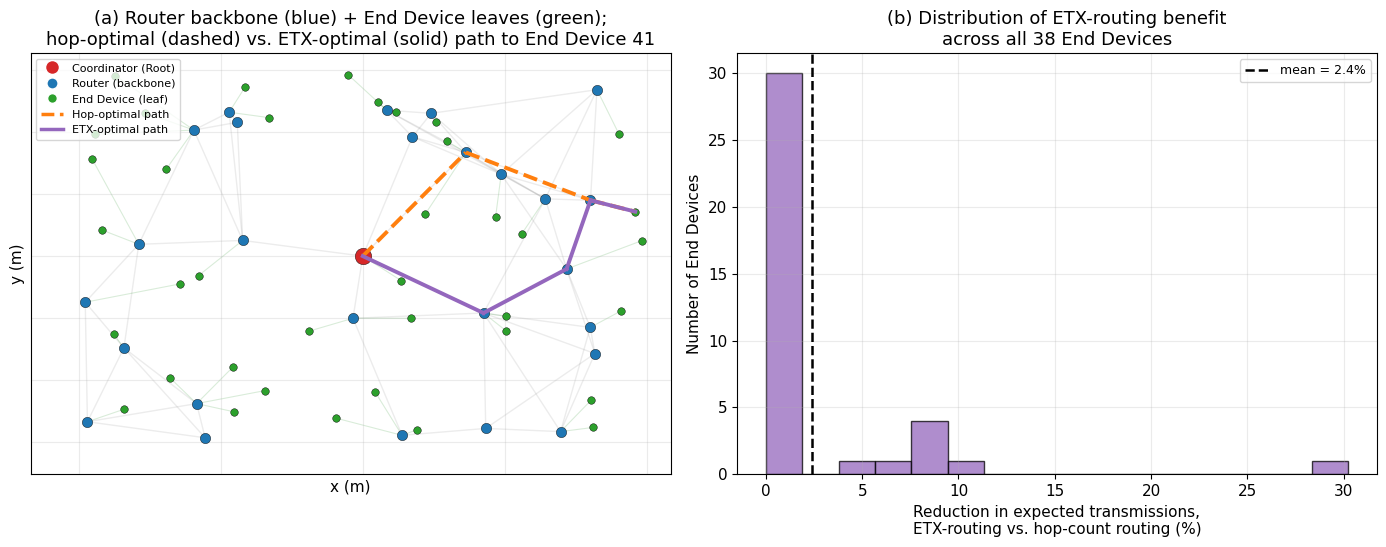

In [3]:
# ── Figure 19.1: hop-count vs. ETX routing on the Router backbone ──────
hop_paths = nx.single_source_shortest_path(B, root)
etx_len, etx_paths = nx.single_source_dijkstra(B, root, weight='etx')

def path_cost(path, w):
    return sum(B.edges[u, v][w] for u, v in zip(path[:-1], path[1:]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax = axes[0]
nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.15, edge_color='gray')
nx.draw_networkx_nodes(B, pos, ax=ax, node_color='tab:blue', node_size=55,
                        linewidths=0.3, edgecolors='k')
nx.draw_networkx_nodes(B, pos, nodelist=[root], ax=ax, node_color='tab:red',
                        node_size=140, linewidths=0.3, edgecolors='k')
for ed, info in pm.items():
    p0, p1 = pos[ed], pos[info['parent']]
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='green', alpha=0.15, lw=0.8, zorder=1)
xs = [pos[k][0] for k in pm]; ys = [pos[k][1] for k in pm]
ax.scatter(xs, ys, s=30, color='tab:green', edgecolor='k', linewidths=0.3, zorder=3)

ed_dest = 41
parent = pm[ed_dest]['parent']
hop_full = hop_paths[parent] + [ed_dest]
etx_full = etx_paths[parent] + [ed_dest]
for u, v in zip(hop_full[:-1], hop_full[1:]):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='tab:orange', lw=2.8, ls='--', zorder=4)
for u, v in zip(etx_full[:-1], etx_full[1:]):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='tab:purple', lw=2.8, zorder=4)
ax.set_title(f'(a) Router backbone (blue) + End Device leaves (green);\n'
             f'hop-optimal (dashed) vs. ETX-optimal (solid) path to End Device {ed_dest}')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Coordinator (Root)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='Router (backbone)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=7, label='End Device (leaf)'),
    Line2D([0], [0], color='tab:orange', lw=2.5, ls='--', label='Hop-optimal path'),
    Line2D([0], [0], color='tab:purple', lw=2.5, label='ETX-optimal path'),
], loc='upper left', fontsize=8)

ax = axes[1]
diffs = []
for ed, info in pm.items():
    parent = info['parent']
    hop_total = path_cost(hop_paths[parent], 'etx') + info['etx']
    etx_total = etx_len[parent] + info['etx']
    if hop_total > 0:
        diffs.append((hop_total - etx_total) / hop_total * 100)
ax.hist(diffs, bins=16, color='tab:purple', alpha=0.75, edgecolor='k')
ax.axvline(np.mean(diffs), color='k', ls='--', label=f'mean = {np.mean(diffs):.1f}%')
ax.set_xlabel('Reduction in expected transmissions,\nETX-routing vs. hop-count routing (%)')
ax.set_ylabel('Number of End Devices')
ax.set_title(f'(b) Distribution of ETX-routing benefit\nacross all {len(pm)} End Devices')
ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# ── Exercise 19.1 output: worked example + Zigbee-style cost cross-check
hop_path_router = hop_paths[4]           # hop-optimal backbone path to Router 4
etx_path_router = etx_paths[4]           # ETX-optimal backbone path to Router 4
print("Hop-count-optimal path to Router 4:", hop_path_router)
for u, v in zip(hop_path_router[:-1], hop_path_router[1:]):
    e = B.edges[u, v]
    print(f"    {u:2d} -> {v:2d}  dist={e['dist']:5.1f} m  PRR={e['prr']:.3f}  "
          f"ETX={e['etx']:.2f}  zcost={e['zcost']:.0f}")
print(f"    total ETX = {path_cost(hop_path_router,'etx'):.2f}   "
      f"total zcost = {path_cost(hop_path_router,'zcost'):.0f}")

print("\nETX-optimal path to Router 4:", etx_path_router)
for u, v in zip(etx_path_router[:-1], etx_path_router[1:]):
    e = B.edges[u, v]
    print(f"    {u:2d} -> {v:2d}  dist={e['dist']:5.1f} m  PRR={e['prr']:.3f}  "
          f"ETX={e['etx']:.2f}  zcost={e['zcost']:.0f}")
print(f"    total ETX = {etx_len[4]:.2f}   total zcost = {path_cost(etx_path_router,'zcost'):.0f}")

n_diff = sum(1 for x in diffs if x > 2.0)
print(f"\nEnd Devices with a meaningfully different ETX-optimal path (> 2% tolerance): "
      f"{n_diff} / {len(pm)}")
print(f"Mean improvement (differing cases): {np.mean([x for x in diffs if x>2.0]):.1f}%  "
      f"max: {np.max(diffs):.1f}%")

Hop-count-optimal path to Router 4: [0, 12, 4]
     0 -> 12  dist=110.8 m  PRR=0.624  ETX=2.57  zcost=6
    12 ->  4  dist= 95.8 m  PRR=0.507  ETX=3.90  zcost=7
    total ETX = 6.47   total zcost = 13

ETX-optimal path to Router 4: [0, 25, 16, 4]
     0 -> 25  dist= 96.6 m  PRR=0.766  ETX=1.70  zcost=4
    25 -> 16  dist= 68.4 m  PRR=0.884  ETX=1.28  zcost=2
    16 ->  4  dist= 57.9 m  PRR=0.904  ETX=1.22  zcost=2
    total ETX = 4.21   total zcost = 8

End Devices with a meaningfully different ETX-optimal path (> 2% tolerance): 8 / 38
Mean improvement (differing cases): 11.2%  max: 30.2%


### Analysis

The 2-hop path from the Coordinator to Router 4 exists — both links clear
the 0.5-PRR cutoff — but the second hop (Router 12 to Router 4) is barely
inside range (PRR ≈ 0.51). Routing one extra hop through Routers 25 and
16, over three much stronger links, cuts total ETX from 6.47 to 4.21 (a
35% reduction) even though the path is technically longer. The
ZigBee-style cost agrees qualitatively (13 → 8, a 38% reduction). Because
both metrics are computed from the same underlying PRR data, this is not
independent confirmation — it's a robustness check showing the route
choice doesn't depend on which particular function of PRR you use.

Across the whole network, this is a real but concentrated effect: about
a fifth of End Devices have a meaningfully different ETX-optimal path,
with a mean improvement of a few percent and a maximum around 30% in the
best case — a smaller, more honest number than a model that (incorrectly)
let End Devices act as shortcuts would have suggested.

> **Key takeaway.** Hop count is a poor proxy for path quality, but the
> benefit of a link-quality-aware metric is concentrated on routes that
> actually contain a marginal link, not spread evenly across the network.

### Challenge tasks

1. Raise the minimum edge PRR to 0.7 and regenerate the network. Does the
   ETX-routing benefit increase or decrease, and why?
2. Design an alternative 5-level ZigBee-style cost mapping. Does it still
   agree with ETX on the Router-4 worked example?
3. Increase the Router count toward Thread's 32-Router ceiling. Does
   backbone redundancy grow noticeably before the ceiling is reached?
4. Identify the End Devices with the next-largest ETX-routing benefit
   after End Device 41. Do they share a weak link with the worked
   example, or are they independent cases?


---

## Exercise 19.2: Thread Network Formation — Leader Election, REED Promotion, and Route-Cost Propagation


In [5]:
# ── Exercise 19.2: Thread Leader election, REED promotion, propagation ──
rng = np.random.default_rng(77)
mains_powered = {n: (rng.random() < 0.35) for n in B.nodes()}   # illustrative capability flag
# Leader weight: OVERLAPPING ranges, so mains power raises the odds of
# winning election without making the outcome deterministic (toy model).
leader_weight = {n: (10 if mains_powered[n] else 0) + int(rng.integers(0, 128)) for n in B.nodes()}
leader = max(B.nodes(), key=lambda n: leader_weight[n])
print(f"Router-capable devices: {B.number_of_nodes()} (within the 32-Router ceiling)")
print(f"Elected Leader: node {leader}  (weight={leader_weight[leader]}, "
      f"mains-powered={mains_powered[leader]})")

# REED promotion (a didactic heuristic, NOT Thread's real Router Selection
# algorithm): activate only Routers needed as parents, or to connect them
# to the Leader
required_parents = {info['parent'] for info in pm.values()} | {leader}
_, paths_from_leader = nx.single_source_dijkstra(B, leader, weight='tcost')
active = set()
for rp in required_parents:
    active.update(paths_from_leader[rp])
reed = set(B.nodes()) - active
print(f"Active Routers after promotion: {len(active)} / {B.number_of_nodes()}")
print(f"REEDs (not promoted): {sorted(reed)}")

Router-capable devices: 27 (within the 32-Router ceiling)
Elected Leader: node 4  (weight=137, mains-powered=True)
Active Routers after promotion: 23 / 27
REEDs (not promoted): [2, 5, 17, 21]


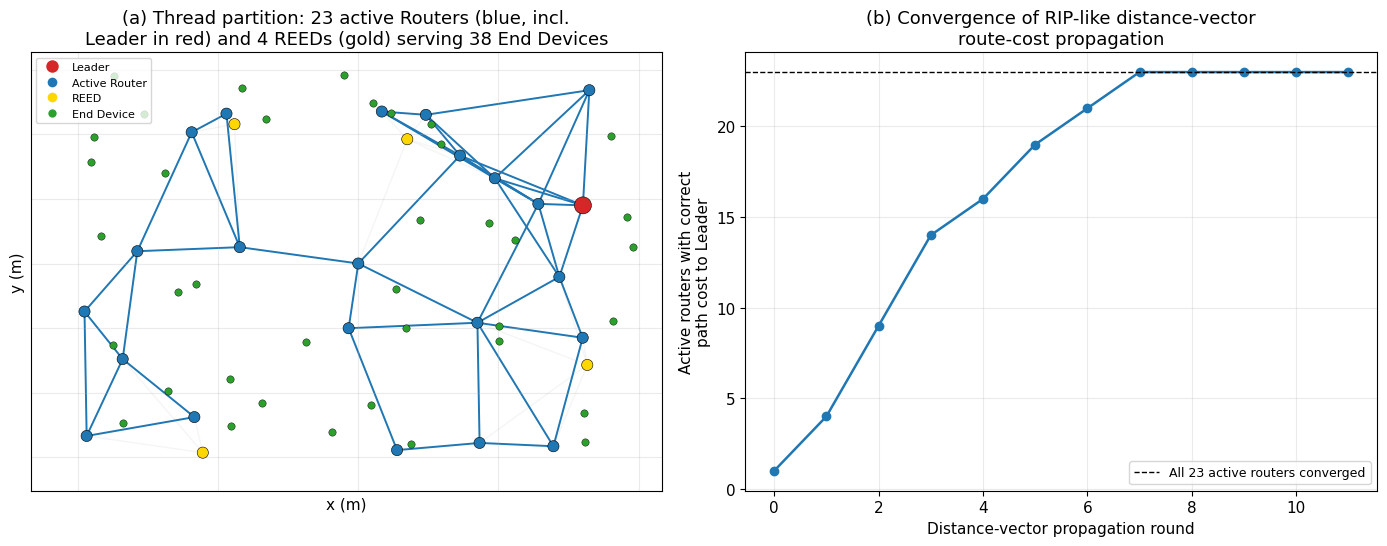

Converged at round: 7


In [6]:
# ── Figure 19.2: active-Router backbone + distance-vector convergence ──
A = B.subgraph(active).copy()
true_cost = nx.single_source_dijkstra_path_length(A, leader, weight='tcost')
dist = {n: float('inf') for n in A.nodes()}; dist[leader] = 0
history = [sum(1 for n in A.nodes() if dist[n] == true_cost[n])]
for rnd in range(1, 12):
    new_dist = dict(dist)
    for n in A.nodes():
        best = dist[n]
        for nb in A.neighbors(n):
            cand = dist[nb] + A.edges[n, nb]['tcost']
            if cand < best: best = cand
        new_dist[n] = best
    dist = new_dist
    history.append(sum(1 for n in A.nodes() if dist[n] == true_cost[n]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax = axes[0]
nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.08, edge_color='gray')
nx.draw_networkx_edges(B, pos, edgelist=list(A.edges()), ax=ax, edge_color='tab:blue', width=1.4)
node_colors, node_sizes = [], []
for n in B.nodes():
    if n == leader: node_colors.append('tab:red'); node_sizes.append(150)
    elif n in active: node_colors.append('tab:blue'); node_sizes.append(65)
    else: node_colors.append('gold'); node_sizes.append(65)
nx.draw_networkx_nodes(B, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        linewidths=0.4, edgecolors='k')
ax.scatter([pos[k][0] for k in pm], [pos[k][1] for k in pm], s=28, color='tab:green',
           edgecolor='k', linewidths=0.3, zorder=3)
ax.set_title(f'(a) Thread partition: {len(active)} active Routers (blue, incl.\n'
             f'Leader in red) and {len(reed)} REEDs (gold) serving {len(pm)} End Devices')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Leader'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='Active Router'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', markersize=8, label='REED'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=7, label='End Device'),
], loc='upper left', fontsize=8)

ax = axes[1]
ax.plot(range(len(history)), history, marker='o', color='tab:blue')
ax.axhline(len(A.nodes()), color='k', ls='--', lw=1, label=f'All {len(A.nodes())} active routers converged')
ax.set_xlabel('Distance-vector propagation round')
ax.set_ylabel('Active routers with correct\npath cost to Leader')
ax.set_title('(b) Convergence of RIP-like distance-vector\nroute-cost propagation')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print('Converged at round:', history.index(len(A.nodes())))

In [7]:
# ── Exercise 19.2 output: hop-count / path-cost correlation ───────────
# IMPORTANT: computed on A (active routers only), NOT B (which also
# contains REEDs) -- a REED is never a valid intermediate hop.
hop_paths_L = nx.single_source_shortest_path(A, leader)
hop_len_L = {t: len(p) - 1 for t, p in hop_paths_L.items()}
nodes_ = [n for n in A.nodes() if n != leader]
hops_arr = np.array([hop_len_L[n] for n in nodes_])
cost_arr = np.array([true_cost.get(n, np.nan) for n in nodes_])
mask = ~np.isnan(cost_arr)
r = np.corrcoef(hops_arr[mask], cost_arr[mask])[0, 1]
print(f"Correlation between hop count and Thread path cost (active routers only): r = {r:.3f}")
print(f"Max path cost to Leader: {np.nanmax(cost_arr):.0f}  (max hops: {hops_arr[mask].max()})")

Correlation between hop count and Thread path cost (active routers only): r = 0.979
Max path cost to Leader: 31  (max hops: 6)


### Analysis

Of the 27 Router-capable devices in the shared backbone, this exercise's
active-router heuristic (a didactic approximation, not Thread's real
Router Selection algorithm) activates an operationally selected subset
that serves every End Device's chosen parent and keeps those parents
connected to the Leader; the rest stay REEDs under this heuristic. In
this comparison model, all 27 backbone-capable devices are instead
configured as Zigbee Routers; unlike Thread, Zigbee does not dynamically
promote and demote devices between Router and End-Device-like roles at
runtime, though a Zigbee network designer can certainly choose to
configure some capable hardware as an End Device from the start.
The real Thread Router Selection algorithm weighs additional factors
beyond bare connectivity too — coverage, path diversity, child count, and
Router-ID availability among them — and wouldn't necessarily agree with
this heuristic on *which* devices to leave as REEDs. Note also that the
elected Leader is **not** the geometrically central device used as
ZigBee's fixed Coordinator: a Thread Leader can be any eligible device,
wherever it sits.

The distance-vector propagation converges within a handful of rounds:
after round 1, only the Routers directly adjacent to the Leader have
their final cost; by the last round, every active Router does — the
concrete mechanism behind Thread's RIP-like route-cost propagation.

> **Key takeaway.** Leader election, REED promotion, and distance-vector
> propagation are three distinct Thread-specific mechanisms — who
> coordinates, who relays, and how they learn their costs — none of which
> ZigBee's simpler always-on-Router model needs to solve the same way.

### Challenge tasks

1. Re-run Leader election with a different seed. Does a mains-powered
   device win more often than chance would predict?
2. Tighten the REED-promotion rule to also promote a Router if it would
   cut some End Device's path cost by more than 50%. How many additional
   Routers get promoted, and does the network stay within the 32-Router
   ceiling?
3. Make the distance-vector relaxation asynchronous (random update order
   each round) and compare rounds-to-convergence.
4. Simulate a second, disjoint Thread partition, then bring it into range
   of the first. What would have to happen for the two to merge?


---

## Exercise 19.3: Self-Healing — Router Failure with End-Device Parent Reselection


In [8]:
# ── Exercise 19.3: self-healing with End-Device parent reselection ─────
def build_case(seed):
    Bc, posc, pmc, su = generate_network(n_routers=27, n_enddevices=38,
                                          width_m=400, height_m=300, seed=seed)
    Tc = spanning_tree_backbone(Bc, 0, weight='etx')
    return Bc, Tc, posc, pmc, su

def failure_trial(Bc, Tc, posc, pmc, su, f, rng):
    router_ids = list(Bc.nodes())
    removable = [r for r in router_ids if r != 0]
    n_remove = int(round(f * len(removable)))
    removed = set(rng.choice(removable, size=n_remove, replace=False)) if n_remove > 0 else set()

    def disconnect_and_cost(topo):
        Hc = topo.copy(); Hc.remove_nodes_from(removed)
        if 0 not in Hc:
            return 1.0, np.nan
        root_component = nx.node_connected_component(Hc, 0)
        base_len = nx.single_source_dijkstra_path_length(topo, 0, weight='etx')
        new_len = nx.single_source_dijkstra_path_length(Hc, 0, weight='etx')
        n_disc, ratios = 0, []
        for ed, info in pmc.items():
            parent = info['parent']
            orig_total = base_len.get(parent, np.inf) + info['etx']
            if parent not in removed and parent in root_component:
                ratios.append((new_len[parent] + info['etx']) / orig_total)
                continue
            cands = candidate_parents(posc[ed], {r: posc[r] for r in router_ids}, router_ids, su, ed)
            found = False
            for (r, p, d, sh) in cands:
                if r not in removed and r in root_component:
                    ratios.append((new_len[r] + etx_generic(d, sh)) / orig_total)
                    found = True; break
            if not found:
                n_disc += 1
        return n_disc / len(pmc), (np.mean(ratios) if ratios else np.nan)

    return disconnect_and_cost(Bc), disconnect_and_cost(Tc)

cases = [build_case(s) for s in range(10)]
fracs = np.linspace(0, 0.5, 11)
mesh_mean, mesh_std, tree_mean, tree_std, cost_infl = [], [], [], [], []
for f in fracs:
    mv, tv, cv = [], [], []
    for ci, case in enumerate(cases):
        for trial in range(20):
            rng = np.random.default_rng(np.random.SeedSequence([555, ci, int(round(f*1000)), trial]))
            (dm, cm), (dt, ct) = failure_trial(*case, f, rng)
            mv.append(dm); tv.append(dt)
            if not np.isnan(cm): cv.append(cm)
    mesh_mean.append(np.mean(mv)); mesh_std.append(np.std(mv))
    tree_mean.append(np.mean(tv)); tree_std.append(np.std(tv))
    cost_infl.append(np.mean(cv) if cv else np.nan)
mesh_mean, mesh_std = np.array(mesh_mean), np.array(mesh_std)
tree_mean, tree_std, cost_infl = np.array(tree_mean), np.array(tree_std), np.array(cost_infl)
print("Self-healing Monte Carlo complete: 10 topologies x 20 failure sets x 11 fractions")

Self-healing Monte Carlo complete: 10 topologies x 20 failure sets x 11 fractions


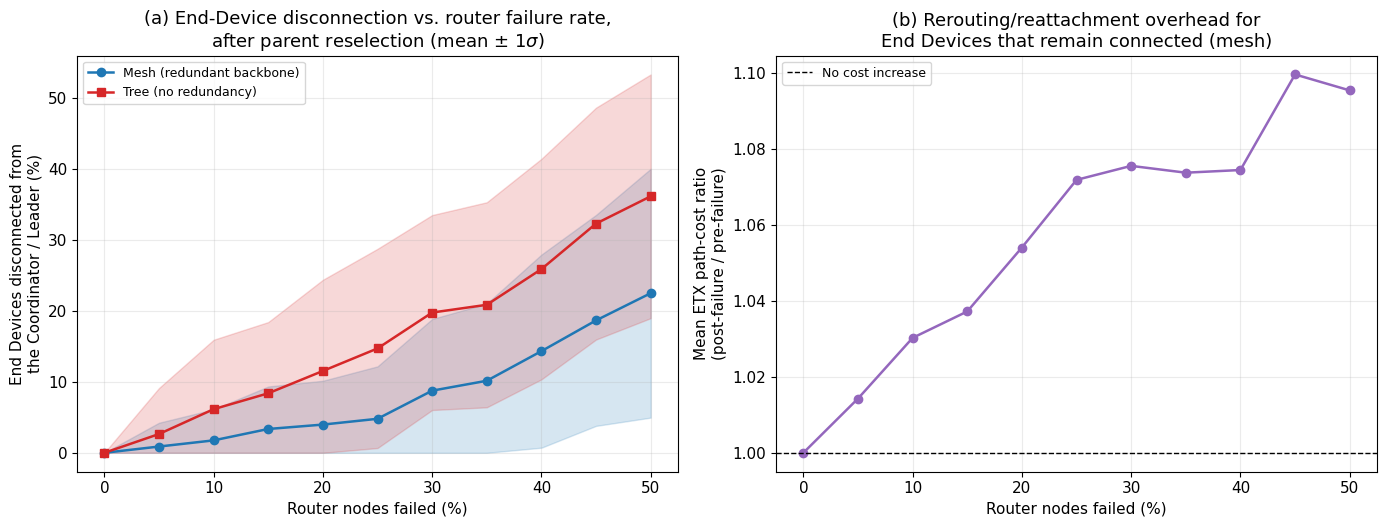

  Failed   Mesh disc.   Tree disc.   Cost ratio
      0%         0.0%         0.0%       1.000x
      5%         0.9%         2.6%       1.014x
     10%         1.8%         6.1%       1.030x
     15%         3.4%         8.4%       1.037x
     20%         4.0%        11.5%       1.054x
     25%         4.8%        14.7%       1.072x
     30%         8.8%        19.8%       1.076x
     35%        10.1%        20.8%       1.074x
     40%        14.3%        25.9%       1.074x
     45%        18.6%        32.3%       1.100x
     50%        22.5%        36.1%       1.095x


In [9]:
# ── Figure 19.3: mesh vs. tree disconnection + rerouting overhead ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ax = axes[0]
ax.plot(fracs*100, mesh_mean*100, color='tab:blue', marker='o', label='Mesh (redundant backbone)')
ax.fill_between(fracs*100, np.clip(mesh_mean-mesh_std,0,1)*100, np.clip(mesh_mean+mesh_std,0,1)*100,
                 color='tab:blue', alpha=0.18)
ax.plot(fracs*100, tree_mean*100, color='tab:red', marker='s', label='Tree (no redundancy)')
ax.fill_between(fracs*100, np.clip(tree_mean-tree_std,0,1)*100, np.clip(tree_mean+tree_std,0,1)*100,
                 color='tab:red', alpha=0.18)
ax.set_xlabel('Router nodes failed (%)')
ax.set_ylabel('End Devices disconnected from\nthe Coordinator / Leader (%)')
ax.set_title('(a) End-Device disconnection vs. router failure rate,\nafter parent reselection (mean $\\pm$ 1$\\sigma$)')
ax.legend(loc='upper left')

ax = axes[1]
ax.plot(fracs*100, cost_infl, color='tab:purple', marker='o')
ax.axhline(1.0, color='k', ls='--', lw=1, label='No cost increase')
ax.set_xlabel('Router nodes failed (%)')
ax.set_ylabel('Mean ETX path-cost ratio\n(post-failure / pre-failure)')
ax.set_title('(b) Rerouting/reattachment overhead for\nEnd Devices that remain connected (mesh)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f"{'Failed':>8s} {'Mesh disc.':>12s} {'Tree disc.':>12s} {'Cost ratio':>12s}")
for f, mm, tm, ci in zip(fracs, mesh_mean, tree_mean, cost_infl):
    print(f"{f*100:7.0f}% {mm*100:11.1f}% {tm*100:11.1f}% {ci:11.3f}x")

### Analysis

At every failure level, the mesh backbone leaves substantially fewer End
Devices disconnected than the tree built from the *same* devices —
because a surviving parent Router whose backbone neighbour or next hop
has failed can often still reach the root through an alternate backbone
path the tree simply does not have. Parent reselection alone already keeps the tree far
from total collapse, so it accounts for a real share of resilience in
*both* topologies; backbone redundancy is what separates mesh from tree
on top of that shared baseline.

The rerouting is not free: End Devices that stay connected see their ETX
path cost inflate gradually as failures accumulate. And recall a
distinction this exercise does not simulate numerically: if the failed
devices include the network's root, a Thread partition elects a new
Leader among survivors, while a ZigBee network's fixed Coordinator has no
equivalent recovery path.

> **Key takeaway.** Self-healing has two separable ingredients —
> topological redundancy (an alternative path exists) and protocol
> mechanisms (route rediscovery, parent reselection) that find and use
> it. A tree still benefits from parent reselection but degrades
> substantially faster than a mesh once router failures accumulate.

### Challenge tasks

1. Disable parent reselection entirely and re-plot. How much of the
   mesh's advantage was due to backbone redundancy vs. reselection?
2. Fail the *k* highest-betweenness-centrality Routers instead of a
   random subset. How much faster does the mesh degrade?
3. Detect partition events (backbone splitting into >1 component) after
   failure. At what failure fraction do they first become likely?
4. Let a REED (Exercise 19.2) be promoted mid-repair if doing so would
   reconnect an otherwise-disconnected End Device. How much does this
   help?


---

## Exercise 19.4: Energy Asymmetry and a Capacity Bottleneck


In [10]:
# ── Exercise 19.4a: Router vs. Sleepy End Device battery life ──────────
RX_MA, TX_MA, SLEEP_UA = 6.9, 7.3, 1.0
BATTERY_ROUTER_MAH, BATTERY_ENDDEV_MAH = 2600.0, 225.0
t_active_s = 0.010
active_ma = (RX_MA + TX_MA) / 2

def router_life_days():
    return BATTERY_ROUTER_MAH / RX_MA / 24          # traffic-independent

def sed_life_years(t_poll_s):
    duty = t_active_s / t_poll_s
    avg_ma = (SLEEP_UA/1000.0)*(1-duty) + active_ma*duty
    return BATTERY_ENDDEV_MAH / avg_ma / 24 / 365.25

router_days = router_life_days()
print(f"Always-on Router (2xAA, {BATTERY_ROUTER_MAH:.0f} mAh): {router_days:.1f} days "
      f"-- essentially independent of relayed traffic volume")
for tp in [1, 5, 10, 30, 60]:
    print(f"  Sleepy End Device, T_poll={tp:3d}s -> {sed_life_years(tp):.2f} years")

Always-on Router (2xAA, 2600 mAh): 15.7 days -- essentially independent of relayed traffic volume
  Sleepy End Device, T_poll=  1s -> 0.36 years
  Sleepy End Device, T_poll=  5s -> 1.69 years
  Sleepy End Device, T_poll= 10s -> 3.17 years
  Sleepy End Device, T_poll= 30s -> 7.62 years
  Sleepy End Device, T_poll= 60s -> 11.76 years


In [11]:
# ── Exercise 19.4b: relay-load / offered relay airtime (lower bound) ───
SYMBOL_US, OVERHEAD_SYMBOLS, BYTE_SYMBOLS, PSDU_BYTES = 16.0, 12, 2, 40
frame_s = (OVERHEAD_SYMBOLS*SYMBOL_US + PSDU_BYTES*BYTE_SYMBOLS*SYMBOL_US) / 1e6
ack_s = (OVERHEAD_SYMBOLS*SYMBOL_US + 5*BYTE_SYMBOLS*SYMBOL_US) / 1e6
turnaround_s = 12*SYMBOL_US/1e6
# radio active time per relayed transaction covers the FULL relay cycle:
# receive inbound data frame + send ACK back to previous hop, THEN
# transmit outbound data frame + receive ACK from next hop -- i.e. TWO
# data frames and TWO ACKs, not one of each. Still NOT a literal
# channel-occupancy measurement, and still excludes CSMA-CA backoff,
# collisions, retries, and neighbour contention.
transaction_s = 2*frame_s + 2*ack_s + 2*turnaround_s
print(f"Radio active time per relayed transaction (full relay cycle): {transaction_s*1000:.3f} ms")

_, paths_root = nx.single_source_dijkstra(B, root, weight='etx')
load = {n: 0 for n in B.nodes()}
for ed, info in pm.items():
    for n in paths_root[info['parent']]:
        load[n] += 1
non_root_load = {n: l for n, l in load.items() if n != root}
busiest = max(non_root_load, key=lambda n: non_root_load[n])
print(f"Busiest non-root relay Router: {busiest}, serving {load[busiest]}/{len(pm)} End Devices")

def offered_airtime(n_devices, t_report):
    '''Lower-bound load proxy: excludes contention, collisions, retries.'''
    return (n_devices / t_report) * transaction_s
for tr in [1, 5, 10, 30, 60, 300]:
    print(f"  T_report={tr:4d}s -> offered relay airtime = {offered_airtime(load[busiest], tr)*100:.3f}%")

Radio active time per relayed transaction (full relay cycle): 4.032 ms
Busiest non-root relay Router: 15, serving 16/38 End Devices
  T_report=   1s -> offered relay airtime = 6.451%
  T_report=   5s -> offered relay airtime = 1.290%
  T_report=  10s -> offered relay airtime = 0.645%
  T_report=  30s -> offered relay airtime = 0.215%
  T_report=  60s -> offered relay airtime = 0.108%
  T_report= 300s -> offered relay airtime = 0.022%


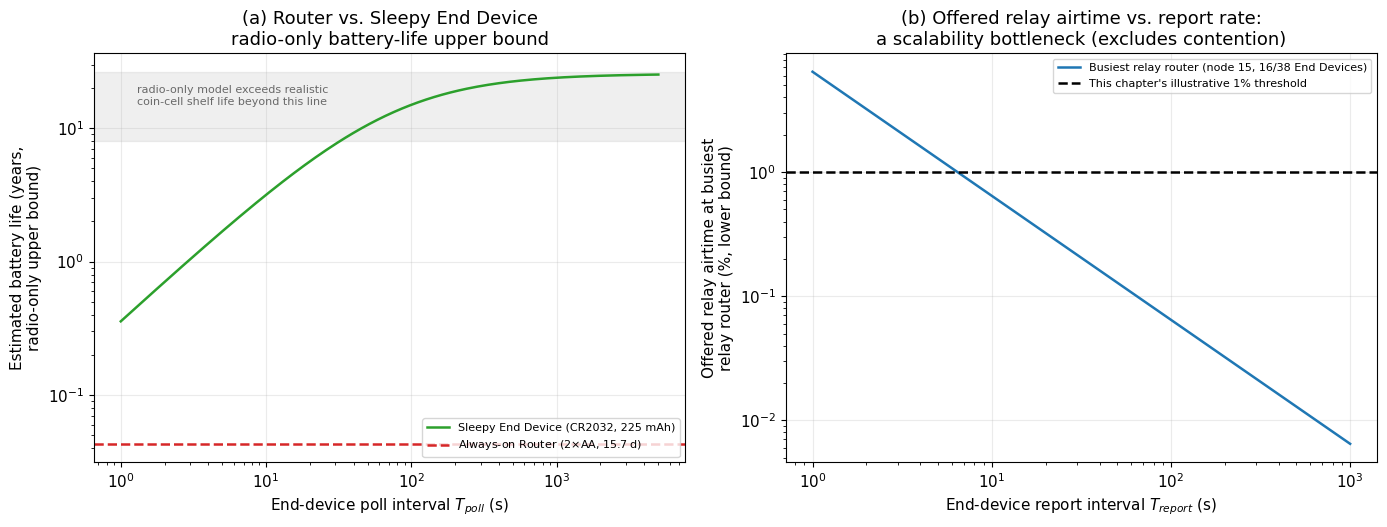

In [12]:
# ── Figure 19.4: battery life and capacity bottleneck ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ax = axes[0]
Tpolls = np.logspace(0, 3.7, 200)
life_years = [sed_life_years(t) for t in Tpolls]
ax.plot(Tpolls, life_years, color='tab:green', label='Sleepy End Device (CR2032, 225 mAh)')
ax.axhline(router_days/365.25, color='tab:red', ls='--',
           label=f'Always-on Router (2$\\times$AA, {router_days:.1f} d)')
ax.axhspan(8, max(life_years)*1.05, color='gray', alpha=0.12)
ax.text(1.3, 15, 'radio-only model exceeds realistic\ncoin-cell shelf life beyond this line', fontsize=8, color='dimgray')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('End-device poll interval $T_{poll}$ (s)')
ax.set_ylabel('Estimated battery life (years,\nradio-only upper bound)')
ax.set_title('(a) Router vs. Sleepy End Device\nradio-only battery-life upper bound')
ax.legend(fontsize=8, loc='lower right')

ax = axes[1]
Treports = np.logspace(0, 3, 200)
util = [offered_airtime(load[busiest], t)*100 for t in Treports]
ax.plot(Treports, util, color='tab:blue',
        label=f'Busiest relay router (node {busiest}, {load[busiest]}/{len(pm)} End Devices)')
ax.axhline(1.0, color='k', ls='--', label="This chapter's illustrative 1% threshold")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('End-device report interval $T_{report}$ (s)')
ax.set_ylabel('Offered relay airtime at busiest\nrelay router (%, lower bound)')
ax.set_title('(b) Offered relay airtime vs. report rate:\na scalability bottleneck (excludes contention)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Analysis

An always-on Router exhausts a pair of AA batteries in about two weeks
*regardless of relayed traffic volume*, since receive-listening current
overwhelms any plausible traffic contribution — precisely why real
ZigBee/Thread Routers are mains-powered infrastructure rather than
battery products. A Sleepy End Device's radio-only upper-bound battery
life crosses one year past a roughly 3-second poll interval and reaches
several years by 5–10 seconds — consistent with published multi-year
IEEE 802.15.4 sensor lifetimes — though beyond roughly 8–10 years the
model's own idealisation (excluding self-discharge) is what's binding,
not the duty cycle.

The busiest non-root relay Router sits on the path for a large share of
End Devices in this deployment. At a brisk 1-second report interval its
radio would already need to be actively engaged for about 6.5% of
every second just for relaying; this chapter's own illustrative
1%-threshold (not a general CSMA/CA rule) is crossed around a 6.5-second
report interval. This is a lower-bound proxy that excludes contention,
collisions, retransmissions, and control traffic, all of which make each
real message more expensive, not less — so a real deployment reaches the
same 1% threshold at a *longer* reporting interval than this model
predicts, meaning it can safely support somewhat less frequent reporting
than the lower bound alone suggests, not more. At the much more typical
60-second cadence used elsewhere in this book, the same Router is
comfortably below the threshold — capacity, not energy, is the
constraint that binds first if this network were pushed toward much more
frequent reporting.

> **Key takeaway.** A mesh network's energy budget is dominated by
> device role, almost independent of traffic; its capacity budget is
> concentrated on whichever Router relays the most End-Device traffic.
> Planning for one does not automatically account for the other.

### Challenge tasks

1. As a hypothetical (non-standard) variant, model a 90%-duty-cycled
   relay and explain why ordinary Routers cannot adopt Sleepy-End-Device-style
   polling without breaking their relaying role.
2. Estimate the battery capacity (mAh) a Router would need to match a
   Sleepy End Device's ~1-year life at a 3-second poll interval. Is that
   plausible for a real primary cell?
3. Recompute the capacity analysis for the second-busiest relay Router.
   How much headroom does it have?
4. Grow the number of End Devices while keeping the Router backbone
   fixed. How does the busiest Router's load, and its 1%-threshold
   crossover report interval, change?
